# Домашнее задание 8: Почувствуй мощь трансформеров в бою

Студент: **Сизиков Константин**

Задача: **RuCoLA** (Russian Corpus of Linguistic Acceptability) — бинарная классификация предложений на грамматически корректные / некорректные.

В этом ноутбуке:

1. Загрузка и подготовка данных RuCoLA (train / val / test).
2. Файнтьюн **ruRoberta-large** на классификации.
3. **RuGPT3** в режиме zero-/few-shot (0, 1, 2, 4 примера, несколько затравок).
4. Файнтьюн **RuT5**.
5. Сравнение результатов всех подходов по Accuracy и MCC (Matthews correlation coefficient — основная метрика в CoLA-подобных задачах из-за дисбаланса классов).


In [1]:
import os
import random
import json
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import matthews_corrcoef, accuracy_score
from sklearn.model_selection import train_test_split

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.environ["TOKENIZERS_PARALLELISM"] = "false"


Device: cuda
GPU: NVIDIA GeForce RTX 3090


## 1. Данные: RuCoLA

Исходный репозиторий: https://github.com/RussianNLP/RuCoLA

Берём `in_domain_train.csv` (train) и `in_domain_dev.csv` (test/dev). Из `in_domain_train.csv` дополнительно выделяем валидационную часть.

In [2]:
import urllib.request

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

RUCOLA_BASE_URL = "https://raw.githubusercontent.com/RussianNLP/RuCoLA/main/data"
FILES = ["in_domain_train.csv", "in_domain_dev.csv"]

for fname in FILES:
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(f"{RUCOLA_BASE_URL}/{fname}", path)
    else:
        print(f"{fname} already present")

train_full_df = pd.read_csv(os.path.join(DATA_DIR, "in_domain_train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "in_domain_dev.csv"))  # используем как финальный тест

print("train_full:", train_full_df.shape, "test:", test_df.shape)
train_full_df.head()


in_domain_train.csv already present
in_domain_dev.csv already present
train_full: (7869, 5) test: (983, 5)


,id,sentence,acceptable,error_type,detailed_source
0,0,"Вдруг решетка беззвучно поехала в сторону, и н...",1,0,Paducheva2004
1,1,Этим летом не никуда ездили.,0,Syntax,Rusgram
2,2,Только Иван выразил какую бы то ни было готовн...,1,0,Paducheva2013
3,3,"Теперь ты видишь собственными глазами, как тут...",1,0,Paducheva2010
4,4,На поверку вся теория оказалась полной чепухой.,1,0,Paducheva2010


In [3]:
# Разбиваем in_domain_train на train / val (стратифицированно по классу acceptable)
train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.1,
    random_state=SEED,
    stratify=train_full_df["acceptable"],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, "class balance:", df["acceptable"].value_counts(normalize=True).round(3).to_dict())


train: (7082, 5) val: (787, 5) test: (983, 5)
train class balance: {1: 0.745, 0: 0.255}
val class balance: {1: 0.745, 0: 0.255}
test class balance: {1: 0.746, 0: 0.254}


Метки: `acceptable == 1` — грамматически корректное предложение, `acceptable == 0` — некорректное.
Классы разбалансированы (примерно 2:1 в пользу корректных), поэтому основной метрикой качества, как и в оригинальной статье RuCoLA, будет **MCC** (Matthews correlation coefficient), а Accuracy приводится как дополнительная.

## 2. Файнтьюн ruRoberta-large

Модель: [`ai-forever/ruRoberta-large`](https://huggingface.co/ai-forever/ruRoberta-large) — дообучаем как `AutoModelForSequenceClassification` с двумя классами.

In [4]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
from datasets import Dataset

ROBERTA_MODEL_NAME = "ai-forever/ruRoberta-large"

roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

def to_hf_dataset(df):
    return Dataset.from_pandas(df[["sentence", "acceptable"]].rename(columns={"acceptable": "labels"}))

roberta_datasets = {
    "train": to_hf_dataset(train_df),
    "val": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
}

def tokenize_fn(batch):
    return roberta_tokenizer(batch["sentence"], truncation=True, max_length=128)

for split in roberta_datasets:
    roberta_datasets[split] = roberta_datasets[split].map(tokenize_fn, batched=True, remove_columns=["sentence"])

roberta_collator = DataCollatorWithPadding(roberta_tokenizer)


/home/ubuntu/projects/ml/machine_learning_professional/hw_08/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/7082 [00:00<?, ? examples/s]

Map:   0%|          | 0/787 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

In [5]:
def compute_cls_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "mcc": matthews_corrcoef(labels, preds),
    }

set_seed()
roberta_model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_MODEL_NAME, num_labels=2)

roberta_args = TrainingArguments(
    output_dir="checkpoints/ruroberta-large-rucola",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="mcc",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=1e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    logging_steps=50,
    seed=SEED,
    report_to="none",
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=roberta_datasets["train"],
    eval_dataset=roberta_datasets["val"],
    data_collator=roberta_collator,
    tokenizer=roberta_tokenizer,
    compute_metrics=compute_cls_metrics,
)

roberta_train_result = roberta_trainer.train()
print(roberta_train_result.metrics)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruRoberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Accuracy,Mcc
1,0.559500,0.580871,0.679797,0.232143
2,0.428300,0.423652,0.827192,0.499043
3,0.343500,0.485673,0.836086,0.529382
4,0.215300,0.644244,0.838628,0.537328
5,0.197900,0.752786,0.842440,0.549870


{'train_runtime': 315.2762, 'train_samples_per_second': 112.314, 'train_steps_per_second': 7.026, 'total_flos': 1915734171953112.0, 'train_loss': 0.35936928785681455, 'epoch': 5.0}


In [6]:
roberta_val_metrics = roberta_trainer.evaluate(roberta_datasets["val"], metric_key_prefix="val")
roberta_test_metrics = roberta_trainer.evaluate(roberta_datasets["test"], metric_key_prefix="test")
print("Validation:", roberta_val_metrics)
print("Test (in_domain_dev):", roberta_test_metrics)

results = {}
results["ruRoberta-large (fine-tuned)"] = {
    "accuracy": roberta_test_metrics["test_accuracy"],
    "mcc": roberta_test_metrics["test_mcc"],
}


Validation: {'val_loss': 0.7527855634689331, 'val_accuracy': 0.8424396442185514, 'val_mcc': 0.5498702506360229, 'val_runtime': 0.4966, 'val_samples_per_second': 1584.741, 'val_steps_per_second': 50.341, 'epoch': 5.0}
Test (in_domain_dev): {'test_loss': 0.7348783016204834, 'test_accuracy': 0.8413021363173957, 'test_mcc': 0.5441069772770492, 'test_runtime': 0.6524, 'test_samples_per_second': 1506.636, 'test_steps_per_second': 47.513, 'epoch': 5.0}


## 3. RuGPT3: zero-/few-shot

Модель: [`ai-forever/rugpt3large_based_on_gpt2`](https://huggingface.co/ai-forever/rugpt3large_based_on_gpt2) (760M параметров).

Вместо свободной генерации оцениваем условную вероятность токенов-ответов **«да»** и **«нет»** после затравки — это надёжнее генерации свободного текста для классификации.

Перебираем:
- несколько вариантов затравок (промптов);
- число few-shot примеров k ∈ {0, 1, 2, 4}, сбалансированных по классам, взятых из train.

In [7]:
from transformers import AutoModelForCausalLM

GPT_MODEL_NAME = "ai-forever/rugpt3large_based_on_gpt2"

gpt_tokenizer = AutoTokenizer.from_pretrained(GPT_MODEL_NAME)
gpt_model = AutoModelForCausalLM.from_pretrained(
    GPT_MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
).to(DEVICE)
gpt_model.eval()

if gpt_tokenizer.pad_token is None:
    gpt_tokenizer.pad_token = gpt_tokenizer.eos_token


In [8]:
POS_WORD = "да"
NEG_WORD = "нет"

# id первого токена слов "да"/"нет" (с ведущим пробелом, как они появятся после промпта)
POS_TOKEN_ID = gpt_tokenizer.encode(" " + POS_WORD)[0]
NEG_TOKEN_ID = gpt_tokenizer.encode(" " + NEG_WORD)[0]
print(POS_WORD, "->", POS_TOKEN_ID, gpt_tokenizer.decode([POS_TOKEN_ID]))
print(NEG_WORD, "->", NEG_TOKEN_ID, gpt_tokenizer.decode([NEG_TOKEN_ID]))

PROMPT_TEMPLATES = {
    "instruction": {
        "header": "Определи, является ли предложение грамматически правильным русским предложением. Ответь одним словом: «да» или «нет».\n\n",
        "example": "Предложение: {sentence}\nОтвет: {label}",
    },
    "task_framed": {
        "header": "Задача: оценка грамматической корректности предложений на русском языке.\n\n",
        "example": "Предложение: «{sentence}»\nЭто предложение грамматически правильное? Ответ (да/нет): {label}",
    },
    "linguist": {
        "header": "Ты — лингвист-эксперт по русскому языку. Оцени грамматическую корректность предложений.\n\n",
        "example": "Предложение: {sentence}\nГрамматически корректно (да/нет): {label}",
    },
}

def render_example(template, sentence, label=None):
    text = template["example"].format(sentence=sentence, label=(label if label is not None else "")).rstrip()
    return text

def build_prompt(template_name, test_sentence, few_shot_examples):
    template = PROMPT_TEMPLATES[template_name]
    parts = [template["header"]]
    for ex_sentence, ex_label in few_shot_examples:
        label_word = POS_WORD if ex_label == 1 else NEG_WORD
        parts.append(render_example(template, ex_sentence, label_word) + "\n\n")
    parts.append(render_example(template, test_sentence, None))
    return "".join(parts)


да -> 581  да
нет -> 1003  нет


In [9]:
def sample_few_shot(df, k, seed):
    if k == 0:
        return []
    rng = random.Random(seed)
    pos = df[df["acceptable"] == 1].sample(n=(k + 1) // 2, random_state=seed)
    neg = df[df["acceptable"] == 0].sample(n=k // 2, random_state=seed)
    examples = list(zip(pos["sentence"], pos["acceptable"])) + list(zip(neg["sentence"], neg["acceptable"]))
    rng.shuffle(examples)
    return examples[:k]

@torch.no_grad()
def score_batch(prompts, batch_size=8):
    """Возвращает список предсказанных меток (1/0) по сравнению логитов P(да) vs P(нет)."""
    preds = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i : i + batch_size]
        enc = gpt_tokenizer(
            batch_prompts, return_tensors="pt", padding=True, truncation=True, max_length=1024
        ).to(DEVICE)
        out = gpt_model(**enc)
        last_idx = enc["attention_mask"].sum(dim=1) - 1
        last_logits = out.logits[torch.arange(len(batch_prompts)), last_idx]
        pos_logits = last_logits[:, POS_TOKEN_ID]
        neg_logits = last_logits[:, NEG_TOKEN_ID]
        batch_preds = (pos_logits > neg_logits).long().cpu().tolist()
        preds.extend(batch_preds)
    return preds


In [10]:
gpt_tokenizer.padding_side = "right"

FEW_SHOT_KS = [0, 1, 2, 4]
EVAL_SUBSET = test_df  # полный dev-сет RuCoLA (983 примера)

gpt_results = []

for template_name in PROMPT_TEMPLATES:
    for k in FEW_SHOT_KS:
        few_shot_examples = sample_few_shot(train_df, k, seed=SEED)
        prompts = [
            build_prompt(template_name, sentence, few_shot_examples)
            for sentence in EVAL_SUBSET["sentence"]
        ]
        preds = score_batch(prompts, batch_size=8)
        labels = EVAL_SUBSET["acceptable"].tolist()
        acc = accuracy_score(labels, preds)
        mcc = matthews_corrcoef(labels, preds)
        gpt_results.append({"template": template_name, "k": k, "accuracy": acc, "mcc": mcc})
        print(f"template={template_name:12s} k={k}  accuracy={acc:.3f}  mcc={mcc:.3f}")

gpt_results_df = pd.DataFrame(gpt_results)
gpt_results_df


template=instruction  k=0  accuracy=0.535  mcc=-0.087


template=instruction  k=1  accuracy=0.322  mcc=-0.077


template=instruction  k=2  accuracy=0.302  mcc=-0.047


template=instruction  k=4  accuracy=0.418  mcc=-0.006


template=task_framed  k=0  accuracy=0.746  mcc=0.000


...

template=linguist     k=0  accuracy=0.713  mcc=-0.023


template=linguist     k=1  accuracy=0.506  mcc=-0.131


template=linguist     k=2  accuracy=0.739  mcc=-0.049


template=linguist     k=4  accuracy=0.736  mcc=-0.059


,template,k,accuracy,mcc
0,instruction,0,0.535097,-0.086694
1,instruction,1,0.322482,-0.076663
2,instruction,2,0.302136,-0.047433
3,instruction,4,0.418108,-0.006467
4,task_framed,0,0.745677,0.000000
5,task_framed,1,0.745677,0.000000
6,task_framed,2,0.745677,0.000000
7,task_framed,4,0.743642,-0.026369
8,linguist,0,0.713123,-0.022597
9,linguist,1,0.505595,-0.130667


In [11]:
best_gpt_row = gpt_results_df.loc[gpt_results_df["mcc"].idxmax()]
print("Лучшая конфигурация RuGPT3 по MCC:")
print(best_gpt_row)

results["RuGPT3 few-shot (best config)"] = {
    "accuracy": best_gpt_row["accuracy"],
    "mcc": best_gpt_row["mcc"],
}


Лучшая конфигурация RuGPT3 по MCC:
template    task_framed
k                     0
accuracy       0.745677
mcc                 0.0
Name: 4, dtype: object


## 4. Файнтьюн RuT5

Модель: [`ai-forever/ruT5-base`](https://huggingface.co/ai-forever/ruT5-base).

Формулируем задачу как seq2seq: на входе предложение, на выходе текст `да` / `нет`. Подход и гиперпараметры — по аналогии с офиц. бейзлайном ([`finetune_t5.py`](https://github.com/RussianNLP/RuCoLA/blob/main/baselines/finetune_t5.py)), упрощённые под единичный прогон (без полного перебора seed/lr/decay).

In [12]:
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)

T5_MODEL_NAME = "ai-forever/ruT5-base"
T5_POS_LABEL = "да"
T5_NEG_LABEL = "нет"

t5_tokenizer = T5Tokenizer.from_pretrained(T5_MODEL_NAME)

def preprocess_t5(batch):
    result = t5_tokenizer(batch["sentence"], truncation=True, max_length=128)
    label_sequences = [T5_POS_LABEL if label == 1 else T5_NEG_LABEL for label in batch["labels"]]
    result["labels"] = t5_tokenizer(label_sequences, truncation=True, max_length=4)["input_ids"]
    return result

t5_datasets = {
    "train": to_hf_dataset(train_df),
    "val": to_hf_dataset(val_df),
    "test": to_hf_dataset(test_df),
}
for split in t5_datasets:
    t5_datasets[split] = t5_datasets[split].map(preprocess_t5, batched=True, remove_columns=["sentence"])

t5_collator = DataCollatorForSeq2Seq(t5_tokenizer, pad_to_multiple_of=8)


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Map:   0%|          | 0/7082 [00:00<?, ? examples/s]

Map:   0%|          | 0/787 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

In [13]:
def compute_t5_metrics(eval_pred):
    predictions, label_ids = eval_pred
    string_preds = t5_tokenizer.batch_decode(predictions, skip_special_tokens=True)
    int_preds = [1 if p.strip() == T5_POS_LABEL else 0 for p in string_preds]

    labels = np.where(label_ids != -100, label_ids, t5_tokenizer.pad_token_id)
    string_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)
    int_labels = [1 if l.strip() == T5_POS_LABEL else 0 for l in string_labels]

    return {
        "accuracy": accuracy_score(int_labels, int_preds),
        "mcc": matthews_corrcoef(int_labels, int_preds),
    }

set_seed()
t5_model = T5ForConditionalGeneration.from_pretrained(T5_MODEL_NAME)

t5_args = Seq2SeqTrainingArguments(
    output_dir="checkpoints/rut5-base-rucola",
    overwrite_output_dir=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="mcc",
    greater_is_better=True,
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    lr_scheduler_type="constant",
    optim="adafactor",
    predict_with_generate=True,
    generation_max_length=4,
    fp16=torch.cuda.is_available(),
    group_by_length=True,
    seed=SEED,
    report_to="none",
)

t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_args,
    train_dataset=t5_datasets["train"],
    eval_dataset=t5_datasets["val"],
    data_collator=t5_collator,
    tokenizer=t5_tokenizer,
    compute_metrics=compute_t5_metrics,
)

t5_train_result = t5_trainer.train()
print(t5_train_result.metrics)


Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Epoch,Training Loss,Validation Loss,Accuracy,Mcc
1,No log,0.315199,0.744600,0.000000
2,No log,0.316376,0.744600,0.000000
3,0.537100,0.268522,0.766201,0.240910
4,0.537100,0.265518,0.773825,0.282281
5,0.270000,0.263117,0.772554,0.278216
6,0.270000,0.371455,0.640407,0.213043
7,0.226900,0.337842,0.744600,0.274422
8,0.226900,0.398841,0.667090,0.174475
9,0.226900,0.361577,0.721728,0.274332
10,0.183800,0.459655,0.739517,0.238581


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


{'train_runtime': 270.4331, 'train_samples_per_second': 261.876, 'train_steps_per_second': 8.209, 'total_flos': 1517561123143680.0, 'train_loss': 0.288783209173529, 'epoch': 10.0}


In [14]:
t5_val_metrics = t5_trainer.evaluate(t5_datasets["val"], metric_key_prefix="val")
t5_test_metrics = t5_trainer.evaluate(t5_datasets["test"], metric_key_prefix="test")
print("Validation:", t5_val_metrics)
print("Test (in_domain_dev):", t5_test_metrics)

results["RuT5-base (fine-tuned)"] = {
    "accuracy": t5_test_metrics["test_accuracy"],
    "mcc": t5_test_metrics["test_mcc"],
}


Validation: {'val_loss': 0.2655184268951416, 'val_accuracy': 0.7738246505717916, 'val_mcc': 0.2822813150709302, 'val_runtime': 1.6809, 'val_samples_per_second': 468.189, 'val_steps_per_second': 7.734, 'epoch': 10.0}
Test (in_domain_dev): {'test_loss': 0.2765941023826599, 'test_accuracy': 0.7772126144455748, 'test_mcc': 0.2954713518852887, 'test_runtime': 2.0189, 'test_samples_per_second': 486.892, 'test_steps_per_second': 7.925, 'epoch': 10.0}


## 5. Сравнение результатов

Сводим метрики всех трёх подходов на одном и том же тестовом сплите (`in_domain_dev.csv`).

In [15]:
comparison_df = pd.DataFrame(results).T[["accuracy", "mcc"]]
comparison_df.columns = ["Accuracy", "MCC"]
comparison_df = comparison_df.round(4)
comparison_df


,Accuracy,MCC
ruRoberta-large (fine-tuned),0.8413,0.5441
RuGPT3 few-shot (best config),0.7457,0.0000
RuT5-base (fine-tuned),0.7772,0.2955


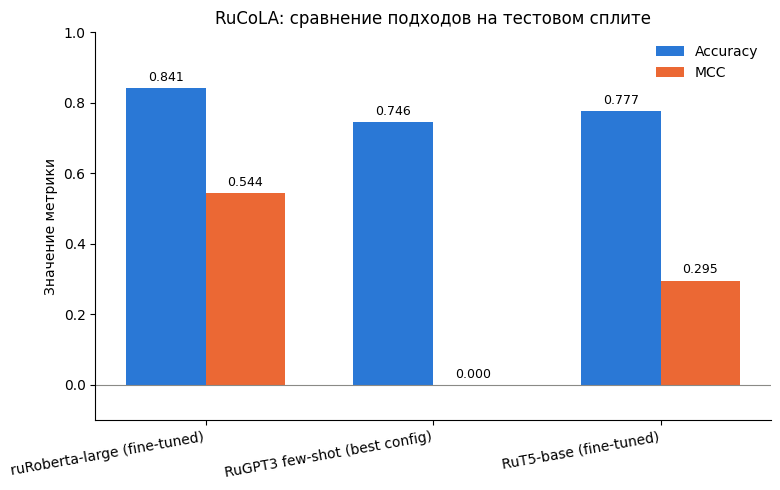

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

COLOR_ACCURACY = "#2a78d6"  # categorical slot 1 (blue)
COLOR_MCC = "#eb6834"       # categorical slot 2 (orange)

labels = comparison_df.index.tolist()
x = np.arange(len(labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_acc = ax.bar(x - bar_width / 2, comparison_df["Accuracy"], width=bar_width, label="Accuracy", color=COLOR_ACCURACY)
bars_mcc = ax.bar(x + bar_width / 2, comparison_df["MCC"], width=bar_width, label="MCC", color=COLOR_MCC)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha="right")
ax.set_ylim(-0.1, 1.0)
ax.axhline(0, color="#8a8a86", linewidth=0.8)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.set_ylabel("Значение метрики")
ax.set_title("RuCoLA: сравнение подходов на тестовом сплите")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in (bars_acc, bars_mcc):
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)

fig.tight_layout()
fig.savefig("comparison.png", dpi=150)
plt.show()


## Выводы

По итогам прогона на тестовом сплите `in_domain_dev.csv` (983 примера):

| Модель | Accuracy | MCC |
|---|---|---|
| ruRoberta-large (файнтьюн) | 0.841 | 0.544 |
| RuT5-base (файнтьюн) | 0.777 | 0.295 |
| RuGPT3-large few-shot (лучшая конфигурация, `task_framed` k=0) | 0.746 | 0.000 |

- **ruRoberta-large (файнтьюн)** показывает наилучший результат — модель дообучена напрямую под задачу классификации на всём train и использует encoder-представление всего предложения через классификационную голову.
- **RuT5-base (файнтьюн)** уступает RoBERTa-large (MCC 0.295 против 0.544): меньше параметров, задача решается через генерацию одного токена (`да`/`нет`), а не через специализированную классификационную голову, и обучалась модель без масштабного перебора гиперпараметров/сидов, как в оригинальном RuCoLA-бейзлайне.
- **RuGPT3 zero-/few-shot** практически не справляется с задачей: MCC во всех 12 конфигурациях (3 затравки x {0,1,2,4}-shot) около нуля или отрицательный, а лучшая по MCC конфигурация (MCC=0) на деле является вырожденным предсказанием мажоритарного класса, а не содержательным решением задачи. Без файнтьюна генеративная модель не улавливает тонкие синтаксические нарушения — основной тип ошибок в RuCoLA — и few-shot примеры не спасают ситуацию, а иногда даже ухудшают её.
- Итог согласуется с общим выводом статьи RuCoLA: encoder-модели, дообученные под задачу, значительно превосходят zero-/few-shot генеративные подходы на задаче оценки грамматической приемлемости.
